## Notebook de treinamento e validação do modelo

In [1]:
## Imports

import sys
from pathlib import Path

## ============================================
# Garante a leitura do modulo src
project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root))
## ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

from src.model.preprocess import save_lemmatized_dataset
from src.model.train import NewsClassifierModel, MODEL_DIR

In [2]:
## Leitura da base processada (usa cache lematizado em data/model/ se já existir, senão gera)

lemmatized_path = MODEL_DIR / "articles_lemmatized.csv"

if not lemmatized_path.exists():
    raw_processed_df = pd.read_csv(project_root / "data" / "processed" / "articles.csv")
    save_lemmatized_dataset(raw_processed_df)

df = pd.read_csv(lemmatized_path)

model = NewsClassifierModel()
metrics = model.train(df, already_lemmatized=True)

model.save()

WindowsPath('C:/Users/cadu2/OneDrive/Área de Trabalho/CASE-AeC/data/model/class_model.joblib')

Métricas gerais

In [3]:
print(f"Acurácia:    {metrics['accuracy']:.4f}")
print(f"F1 (macro):    {metrics['f1_macro']:.4f}")
print(f"F1 (weighted): {metrics['f1_weighted']:.4f}")

Acurácia:    0.9125
F1 (macro):    0.8261
F1 (weighted): 0.9144


Classification report completo (precisão, recall e F1 por categoria)

In [4]:
print(metrics["classification_report"])

                    precision    recall  f1-score   support

               bbc       0.40      0.48      0.44        98
           ciencia       0.69      0.70      0.69       133
           colunas       1.00      1.00      1.00      2151
            comida       0.58      0.71      0.64        83
         cotidiano       0.90      0.88      0.89      1696
          educacao       0.79      0.91      0.85       211
empreendedorsocial       0.79      0.85      0.82        84
  equilibrioesaude       0.54      0.75      0.63       131
           esporte       0.99      0.98      0.98      1972
          folhinha       0.71      0.88      0.78        88
         ilustrada       0.91      0.91      0.91      1561
      ilustrissima       0.56      0.69      0.62       140
           mercado       0.91      0.87      0.89      2095
             mundo       0.93      0.93      0.93      1713
           opiniao       0.95      0.92      0.93       452
    paineldoleitor       0.99      0.98

Matriz de confusão

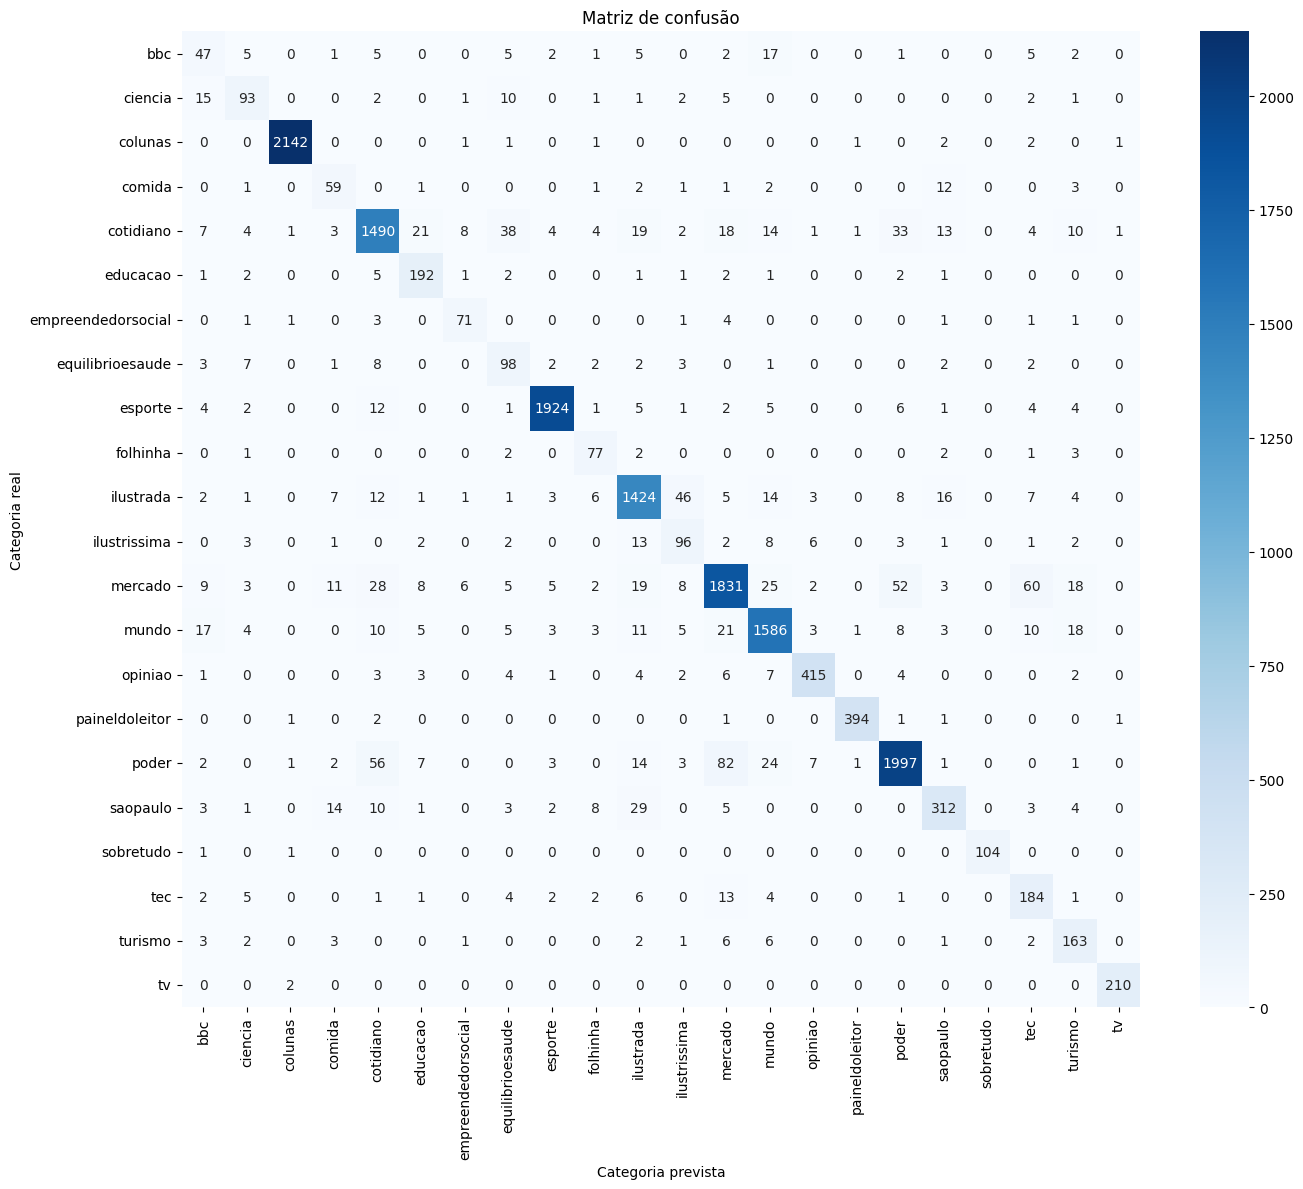

In [5]:
labels = sorted(model.y_test.unique())
cm = confusion_matrix(model.y_test, model.y_pred, labels=labels)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Categoria prevista")
plt.ylabel("Categoria real")
plt.title("Matriz de confusão")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

F1-score por categoria (ordenado do pior para o melhor)

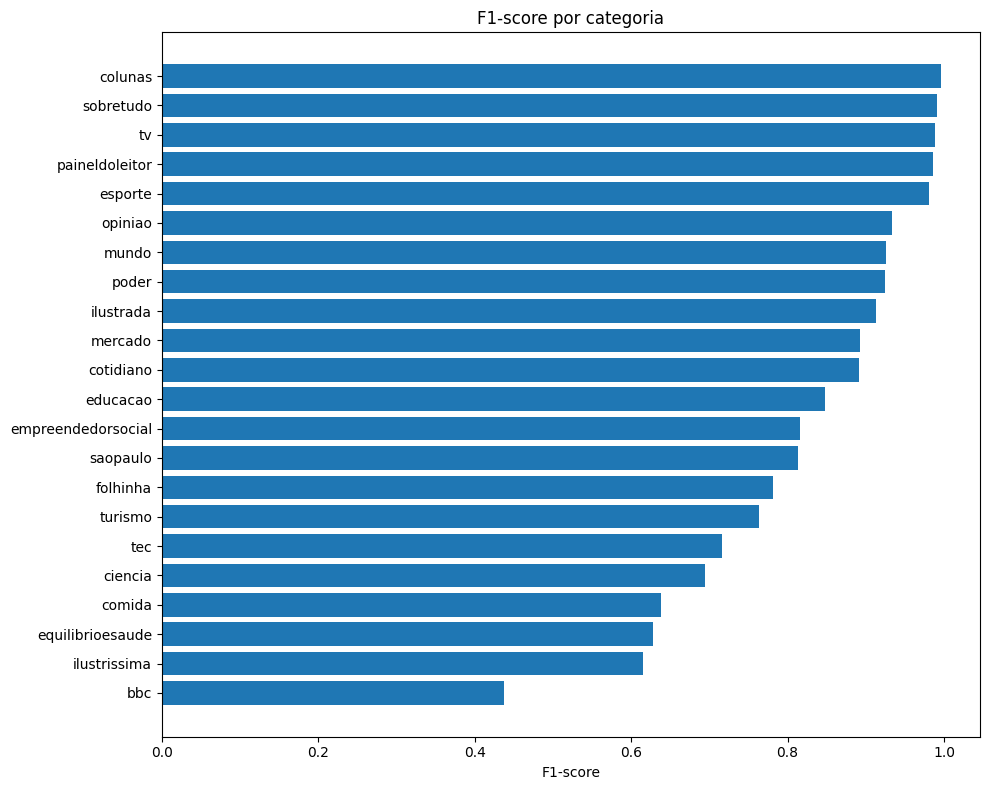

,categoria,precisao,recall,f1,suporte
0,bbc,0.401709,0.479592,0.437209,98
11,ilustrissima,0.558140,0.685714,0.615385,140
7,equilibrioesaude,0.541436,0.748092,0.628205,131
3,comida,0.578431,0.710843,0.637838,83
1,ciencia,0.688889,0.699248,0.694030,133
19,tec,0.638889,0.814159,0.715953,226
20,turismo,0.687764,0.857895,0.763466,190
9,folhinha,0.706422,0.875000,0.781726,88
17,saopaulo,0.838710,0.789873,0.813559,395
6,empreendedorsocial,0.788889,0.845238,0.816092,84


In [6]:
labels = sorted(model.y_test.unique())
precision, recall, f1, support = precision_recall_fscore_support(model.y_test, model.y_pred, labels=labels)

f1_por_categoria = pd.DataFrame({
    "categoria": labels,
    "precisao": precision,
    "recall": recall,
    "f1": f1,
    "suporte": support,
}).sort_values("f1")

plt.figure(figsize=(10, 8))
plt.barh(f1_por_categoria["categoria"], f1_por_categoria["f1"])
plt.xlabel("F1-score")
plt.title("F1-score por categoria")
plt.tight_layout()
plt.show()

f1_por_categoria